<a href="https://colab.research.google.com/github/Saluja50/ted-talk-views-prediction-model/blob/main/ted_talk_views_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - ted talk views prediction model




##### **Project Type**    - Regression
##### **Contribution**    - Individual


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/Saluja50/ted-talk-views-prediction-model




# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [209]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import math
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

### Dataset Loading

In [210]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [211]:
# Load Dataset
dataset = pd.read_csv("/content/drive/MyDrive/Copy of data_ted_talks.csv",encoding = 'latin1')
df = dataset.copy()

### Dataset First View

In [212]:
# Dataset First Look
df.head()

,talk_id,title,speaker_1,all_speakers,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
0,1,Averting the climate crisis,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the worldâ...,3523392,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,"['alternative energy', 'cars', 'climate change...","{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,With the same humor and humanity he exuded in ...,"Thank you so much, Chris. And it's truly a gre..."
1,92,The best stats you've ever seen,Hans Rosling,{0: 'Hans Rosling'},{0: ['global health expert; data visionary']},"{0: 'In Hans Roslingâs hands, data sings. Gl...",14501685,2006-02-22,2006-06-27,TED2006,en,"['ar', 'az', 'bg', 'bn', 'bs', 'cs', 'da', 'de...",628.0,1190,"['Africa', 'Asia', 'Google', 'demo', 'economic...","{2056: ""Own your body's data"", 2296: 'A visual...",https://www.ted.com/talks/hans_rosling_the_bes...,You've never seen data presented like this. Wi...,"About 10 years ago, I took on the task to teac..."
2,7,Simplicity sells,David Pogue,{0: 'David Pogue'},{0: ['technology columnist']},{0: 'David Pogue is the personal technology co...,1920832,2006-02-24,2006-06-27,TED2006,en,"['ar', 'bg', 'de', 'el', 'en', 'es', 'fa', 'fr...",124.0,1286,"['computers', 'entertainment', 'interface desi...","{1725: '10 top time-saving tech tips', 2274: '...",https://www.ted.com/talks/david_pogue_simplici...,New York Times columnist David Pogue takes aim...,"(Music: ""The Sound of Silence,"" Simon & Garfun..."
3,53,Greening the ghetto,Majora Carter,{0: 'Majora Carter'},{0: ['activist for environmental justice']},{0: 'Majora Carter redefined the field of envi...,2664069,2006-02-26,2006-06-27,TED2006,en,"['ar', 'bg', 'bn', 'ca', 'cs', 'de', 'en', 'es...",219.0,1116,"['MacArthur grant', 'activism', 'business', 'c...",{1041: '3 stories of local eco-entrepreneurshi...,https://www.ted.com/talks/majora_carter_greeni...,"In an emotionally charged talk, MacArthur-winn...",If you're here today â and I'm very happy th...
4,66,Do schools kill creativity?,Sir Ken Robinson,{0: 'Sir Ken Robinson'},"{0: ['author', 'educator']}","{0: ""Creativity expert Sir Ken Robinson challe...",65051954,2006-02-25,2006-06-27,TED2006,en,"['af', 'ar', 'az', 'be', 'bg', 'bn', 'ca', 'cs...",4931.0,1164,"['children', 'creativity', 'culture', 'dance',...","{865: 'Bring on the learning revolution!', 173...",https://www.ted.com/talks/sir_ken_robinson_do_...,Sir Ken Robinson makes an entertaining and pro...,Good morning. How are you? (Audience) Good. It...


### Dataset Rows & Columns count

In [213]:
# Dataset Rows & Columns count
df.shape

(4005, 19)

### Dataset Information

In [214]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   talk_id         4005 non-null   int64  
 1   title           4005 non-null   object 
 2   speaker_1       4005 non-null   object 
 3   all_speakers    4001 non-null   object 
 4   occupations     3483 non-null   object 
 5   about_speakers  3502 non-null   object 
 6   views           4005 non-null   int64  
 7   recorded_date   4004 non-null   object 
 8   published_date  4005 non-null   object 
 9   event           4005 non-null   object 
 10  native_lang     4005 non-null   object 
 11  available_lang  4005 non-null   object 
 12  comments        3350 non-null   float64
 13  duration        4005 non-null   int64  
 14  topics          4005 non-null   object 
 15  related_talks   4005 non-null   object 
 16  url             4005 non-null   object 
 17  description     4005 non-null   o

#### Duplicate Values

In [215]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [216]:
# Missing Values/Null Values Count
print(df.isnull().sum())

talk_id             0
title               0
speaker_1           0
all_speakers        4
occupations       522
about_speakers    503
views               0
recorded_date       1
published_date      0
event               0
native_lang         0
available_lang      0
comments          655
duration            0
topics              0
related_talks       0
url                 0
description         0
transcript          0
dtype: int64


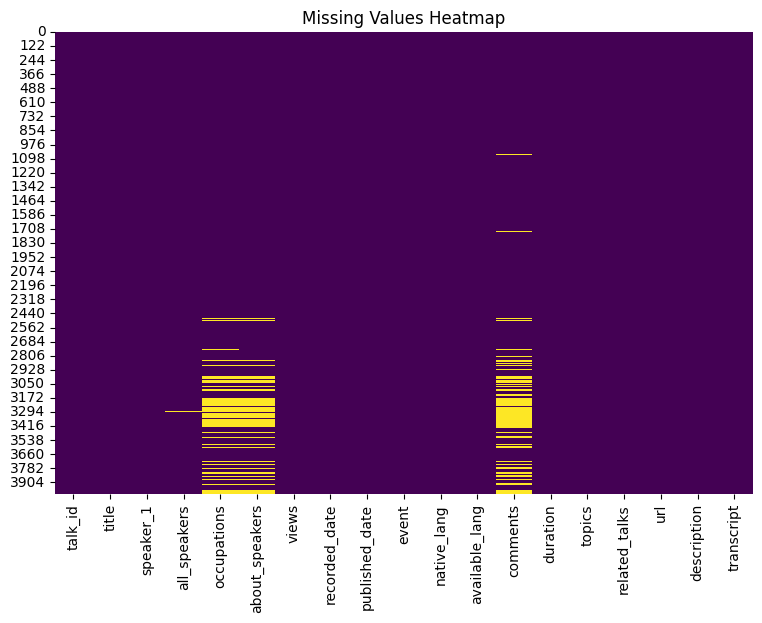

In [217]:
# Visualizing the missing values
# by heat map
plt.figure(figsize=(9,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

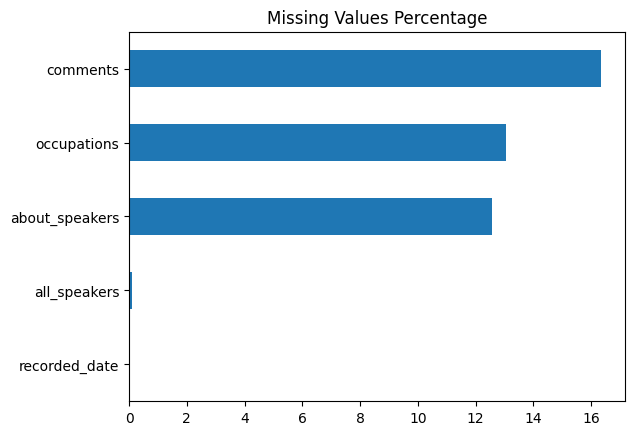

In [218]:
# by percentage plot
null_percent = (df.isnull().sum() / len(df)) * 100

null_percent = null_percent[null_percent > 0]

null_percent.sort_values().plot(kind='barh')
plt.title("Missing Values Percentage")
plt.show()

### What did you know about your dataset?

The dataset contains TED Talks data with a mix of numerical, categorical, and textual features. I observed that most columns are clean, but some like comments, occupations, and about_speakers have significant missing values. The missing data is not randomly distributed, indicating possible data collection issues. I also identified key features like views and comments as important for analysis, while some text heavy columns may not add much value. Overall, the dataset is mostly clean but requires preprocessing before deeper analysis.

## ***2. Understanding Your Variables***

In [219]:
# Dataset Columns
df.columns

Index(['talk_id', 'title', 'speaker_1', 'all_speakers', 'occupations',
       'about_speakers', 'views', 'recorded_date', 'published_date', 'event',
       'native_lang', 'available_lang', 'comments', 'duration', 'topics',
       'related_talks', 'url', 'description', 'transcript'],
      dtype='object')

In [220]:
# Dataset Describe
df.describe()

,talk_id,views,comments,duration
count,4005.000000,4.005000e+03,3350.000000,4005.000000
mean,12432.538327,2.148006e+06,161.997015,724.011236
std,17447.576262,3.451226e+06,268.838922,361.775462
min,1.000000,0.000000e+00,0.000000,60.000000
25%,1252.000000,8.820690e+05,38.000000,393.000000
50%,2333.000000,1.375508e+06,89.000000,738.000000
75%,23777.000000,2.133110e+06,188.000000,974.000000
max,62794.000000,6.505195e+07,6449.000000,3922.000000


### Variables Description

**talk_id**: Unique ID of each talk

**title** : Title of the TED Talk

**speaker_1** : Main speaker of the talk

**all_speakers** : List of all speakers involved in the talk

**occupations** : Professions of the speakers

**about_speakers** : Description or bio of the speakers

**views**: Total number of views of the talk

**recorded_date** : Date when the talk was recorded

**published_date** : Date when the talk was published

**event** : Event where the talk was presented

**native_lang** : Original language of the talk

**available_lang** : Number of languages available for subtitles

**comments** : Total number of comments on the talk

**duration**: Length of the talk in seconds

**topics** : Topics or tags related to the talk

**related_talks** : List of related TED Talks

**url** : Link to the TED Talk

**description** : Short summary of the talk

**transcript** : Full text transcript of the talk



### Check Unique Values for each variable.

In [221]:
# Check Unique Values for each variable.
for i in df.columns:
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  talk_id is 4005 .
No. of unique values in  title is 4005 .
No. of unique values in  speaker_1 is 3274 .
No. of unique values in  all_speakers is 3306 .
No. of unique values in  occupations is 2049 .
No. of unique values in  about_speakers is 2977 .
No. of unique values in  views is 3996 .
No. of unique values in  recorded_date is 1334 .
No. of unique values in  published_date is 2962 .
No. of unique values in  event is 459 .
No. of unique values in  native_lang is 12 .
No. of unique values in  available_lang is 3902 .
No. of unique values in  comments is 601 .
No. of unique values in  duration is 1188 .
No. of unique values in  topics is 3977 .
No. of unique values in  related_talks is 4005 .
No. of unique values in  url is 4005 .
No. of unique values in  description is 4005 .
No. of unique values in  transcript is 4005 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [222]:
# Write your code to make your dataset analysis ready.
# 1.unwanted columns
df = df.drop(['talk_id', 'url', 'related_talks'], axis=1)
df.columns





Index(['title', 'speaker_1', 'all_speakers', 'occupations', 'about_speakers',
       'views', 'recorded_date', 'published_date', 'event', 'native_lang',
       'available_lang', 'comments', 'duration', 'topics', 'description',
       'transcript'],
      dtype='object')

In [223]:
#2. removing missing vslues and filling
df = df.drop(['occupations', 'about_speakers'], axis=1)
df['comments'] = df['comments'].fillna(df['comments'].median())

In [224]:
#3 changing data type and feature engineering
df['published_date'] = pd.to_datetime(df['published_date'])
df['recorded_date'] = pd.to_datetime(df['recorded_date'])
df['year'] = df['published_date'].dt.year
df['engagement'] = df['comments'] / df['views']
df['duration_min'] = df['duration'] / 60

In [225]:
a = [1,2,3,4,5]
b = a

In [226]:
print(b)

[1, 2, 3, 4, 5]


In [227]:
#4converting into numeric
df['title_length'] = df['title'].apply(len)
df['topic_count'] = df['topics'].str.split(',').str.len()

In [228]:
#5 handling skewness
print(df['views'].mean())
print(df['views'].median())

2148005.5737827714
1375508.0


In [229]:
#mean>mode right skewed
#Doing log transformation
df['views'] = np.log1p(df['views'])

In [230]:
#encoding in native lang
df = pd.get_dummies(df, columns=['native_lang'], drop_first=True)

In [231]:
#heavy text columns
df = df.drop(['title', 'description', 'transcript', 'topics'], axis=1)

In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   speaker_1          4005 non-null   object        
 1   all_speakers       4001 non-null   object        
 2   views              4005 non-null   float64       
 3   recorded_date      4004 non-null   datetime64[ns]
 4   published_date     4005 non-null   datetime64[ns]
 5   event              4005 non-null   object        
 6   available_lang     4005 non-null   object        
 7   comments           4005 non-null   float64       
 8   duration           4005 non-null   int64         
 9   year               4005 non-null   int32         
 10  engagement         4005 non-null   float64       
 11  duration_min       4005 non-null   float64       
 12  title_length       4005 non-null   int64         
 13  topic_count        4005 non-null   int64         
 14  native_l

In [233]:
df.head()

,speaker_1,all_speakers,views,recorded_date,published_date,event,available_lang,comments,duration,year,...,native_lang_en,native_lang_es,native_lang_fr,native_lang_hi,native_lang_it,native_lang_ja,native_lang_ko,native_lang_pt,native_lang_pt-br,native_lang_zh-cn
0,Al Gore,{0: 'Al Gore'},15.074935,2006-02-25,2006-06-27,TED2006,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,2006,...,True,False,False,False,False,False,False,False,False,False
1,Hans Rosling,{0: 'Hans Rosling'},16.489775,2006-02-22,2006-06-27,TED2006,"['ar', 'az', 'bg', 'bn', 'bs', 'cs', 'da', 'de...",628.0,1190,2006,...,True,False,False,False,False,False,False,False,False,False
2,David Pogue,{0: 'David Pogue'},14.468270,2006-02-24,2006-06-27,TED2006,"['ar', 'bg', 'de', 'el', 'en', 'es', 'fa', 'fr...",124.0,1286,2006,...,True,False,False,False,False,False,False,False,False,False
3,Majora Carter,{0: 'Majora Carter'},14.795366,2006-02-26,2006-06-27,TED2006,"['ar', 'bg', 'bn', 'ca', 'cs', 'de', 'en', 'es...",219.0,1116,2006,...,True,False,False,False,False,False,False,False,False,False
4,Sir Ken Robinson,{0: 'Sir Ken Robinson'},17.990697,2006-02-25,2006-06-27,TED2006,"['af', 'ar', 'az', 'be', 'bg', 'bn', 'ca', 'cs...",4931.0,1164,2006,...,True,False,False,False,False,False,False,False,False,False


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

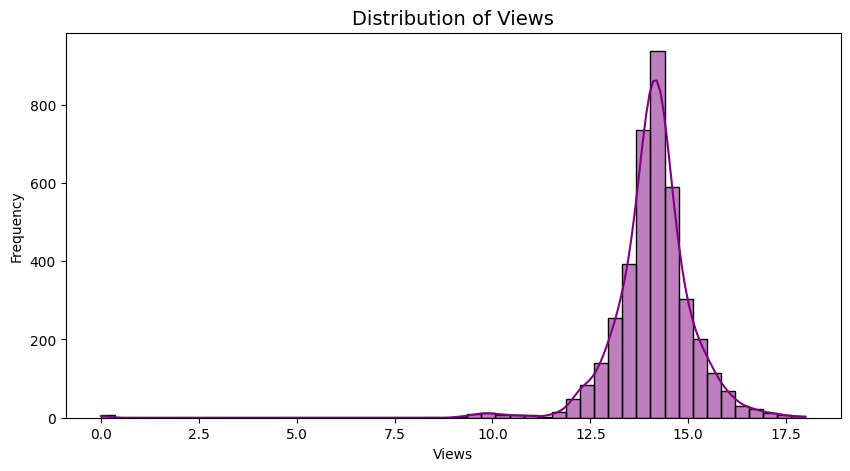

In [234]:
# Chart - 1 distribution of views
plt.figure(figsize=(10,5))
sns.histplot(df['views'], bins=50, kde=True, color='purple')

plt.title("Distribution of Views", fontsize=14)
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()


##### 1. Why did you pick the specific chart?



```
# This is formatted as code
```

To analyze the distribution of views and check skewness after transformation.

##### 2. What is/are the insight(s) found from the chart?

Most TED talks have moderate views, with the majority clustered around the mid-range.Only a small number of talks achieve very high views, indicating that viral success is rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

positive :
Platform has consistent content performance
Most talks reach a reasonable audience

negative:
Only few talks achieve massive reach
Opportunity gap in scaling content success

#### Chart - 2

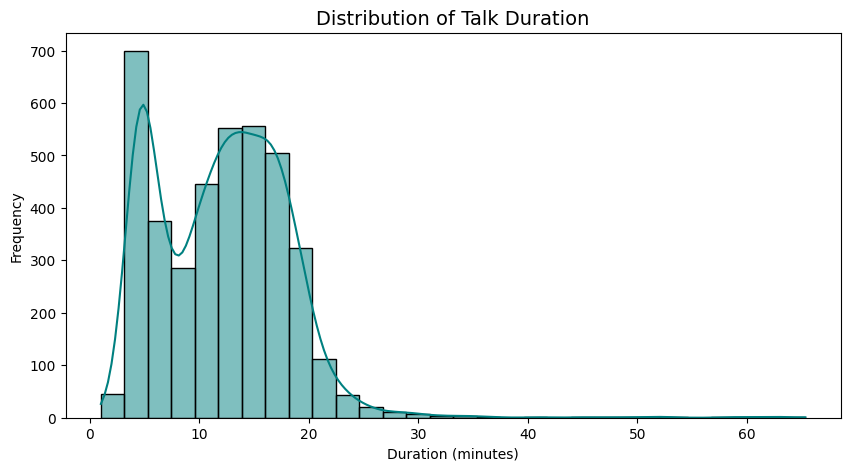

In [235]:
# Chart - Distribution of Duration
plt.figure(figsize=(10,5))
sns.histplot(df['duration_min'], bins=30, kde=True, color='teal')

plt.title("Distribution of Talk Duration", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand typical length of TED talks and whether longer talks are common or rare

##### 2. What is/are the insight(s) found from the chart?

Most TED talks are concentrated between 10 to 20 minutes. Very short and very long talks are relatively less common.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Positive:

Helps define ideal talk duration

Useful for content creators to optimize length

Negative:

Very long talks may lose audience attention

Very short talks may lack depth


#### Chart - 3

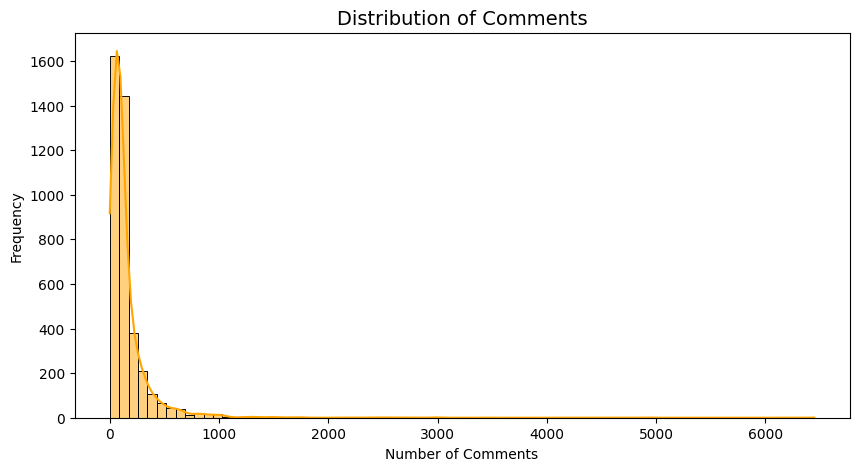

In [236]:
# Chart - 3 Distribution of Comments
plt.figure(figsize=(10,5))
sns.histplot(df['comments'], bins=75, kde=True, color='orange')

plt.title("Distribution of Comments", fontsize=14)
plt.xlabel("Number of Comments")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how audience interacts with talks,
Whether engagement is evenly distributed or not

##### 2. What is/are the insight(s) found from the chart?

Most talks receive low to moderate number of comments.

A few talks get very high comments, indicating strong engagement spikes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

Highly engaging talks can build strong community interaction

Opportunity to learn what drives discussions

Negative:

Majority of talks have low engagement

#### Chart - 4

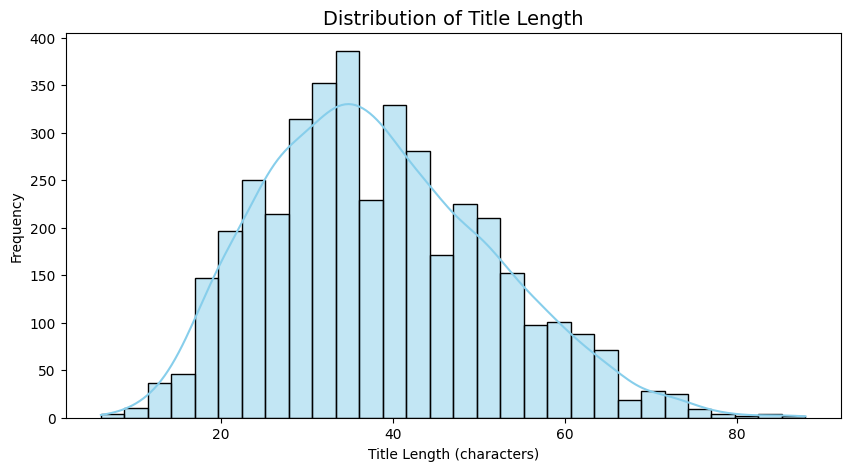

In [237]:
# Chart - 4 Distribution of Title Length
plt.figure(figsize=(10,5))
sns.histplot(df['title_length'], bins=30, kde=True, color='skyblue')

plt.title("Distribution of Title Length", fontsize=14)
plt.xlabel("Title Length (characters)")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how long TED talk titles usually are
,Whether short or long titles are common

##### 2. What is/are the insight(s) found from the chart?

Most TED talk titles have moderate length .
Extremely short or very long titles are rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps define ideal title length for clarity and engagement
Balanced titles improve readability

#### Chart - 5

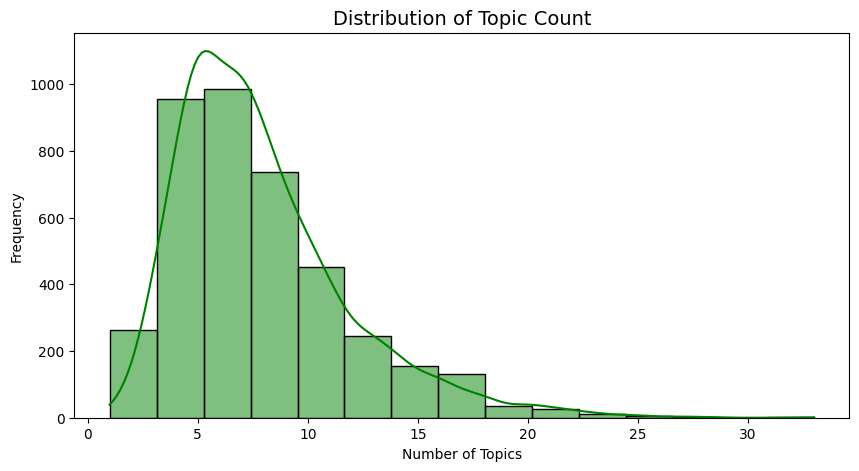

In [238]:
# Chart - 5 Distribution of Topic Count
plt.figure(figsize=(10,5))
sns.histplot(df['topic_count'], bins=15, kde=True, color='green')

plt.title("Distribution of Topic Count", fontsize=14)
plt.xlabel("Number of Topics")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how many topics a typical talk covers and
Whether talks are focused or broad

##### 2. What is/are the insight(s) found from the chart?

Most TED talks cover a small number of topics

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focused talks are easier to understand and
improves audience retention

#### Chart - 6

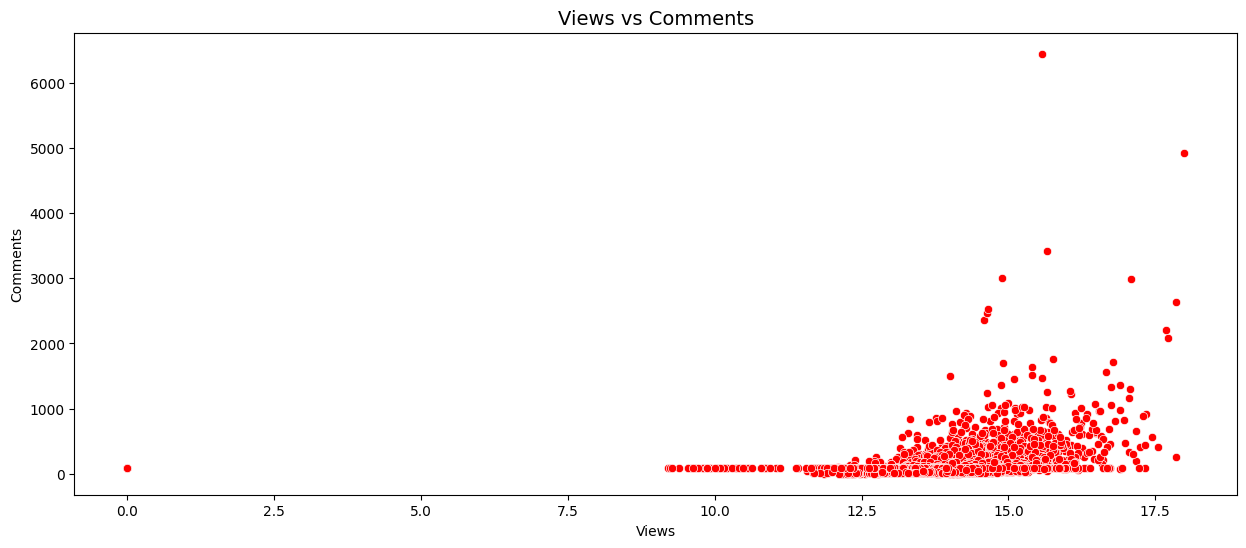

In [239]:
# Chart - 6 Views vs Comments
plt.figure(figsize=(15,6))
sns.scatterplot(x='views', y='comments', data=df, color='red')

plt.title("Views vs Comments", fontsize=14)
plt.xlabel("Views")
plt.ylabel("Comments")

plt.show()

##### 1. Why did you pick the specific chart?

To understand Relationship between views and comments

##### 2. What is/are the insight(s) found from the chart?

There is a positive relationship between views and comments.
Talks with higher views generally receive more comments .

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Increasing views can directly boost engagement



#### Chart - 7

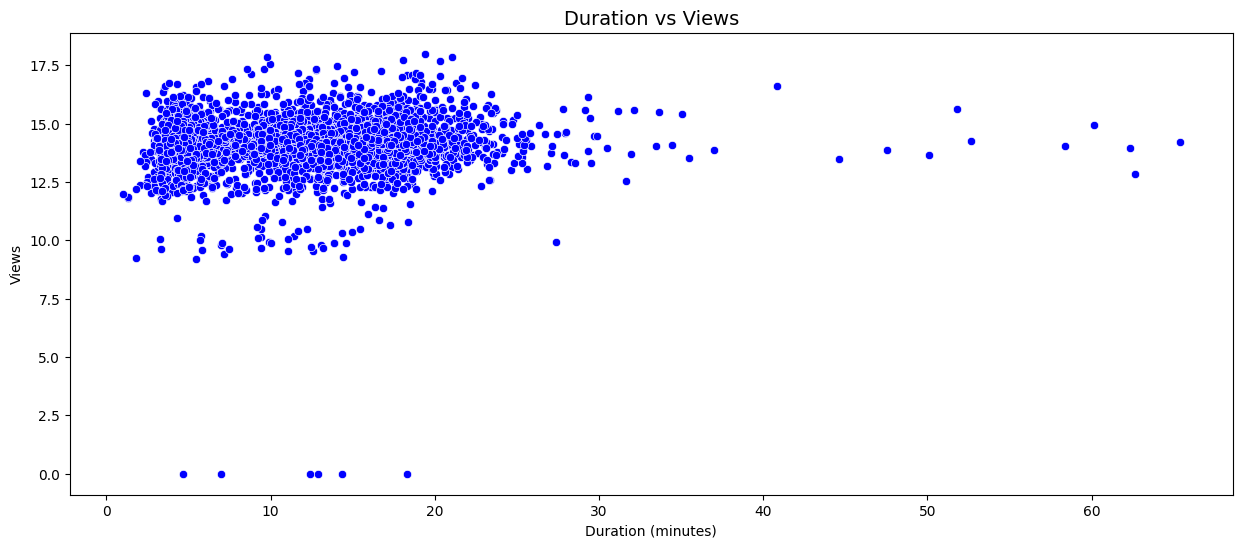

In [240]:
# Chart - 7 Duration vs Views
plt.figure(figsize=(15,6))
sns.scatterplot(x='duration_min', y='views', data=df, color='blue')

plt.title("Duration vs Views", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Views")

plt.show()

##### 1. Why did you pick the specific chart?

To check if longer talk = more views?

##### 2. What is/are the insight(s) found from the chart?

There is no strong relationship between duration and views.
Both short and long talks can perform well, indicating duration alone doesn't decide success.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Success depends more on quality than length

#### Chart - 8

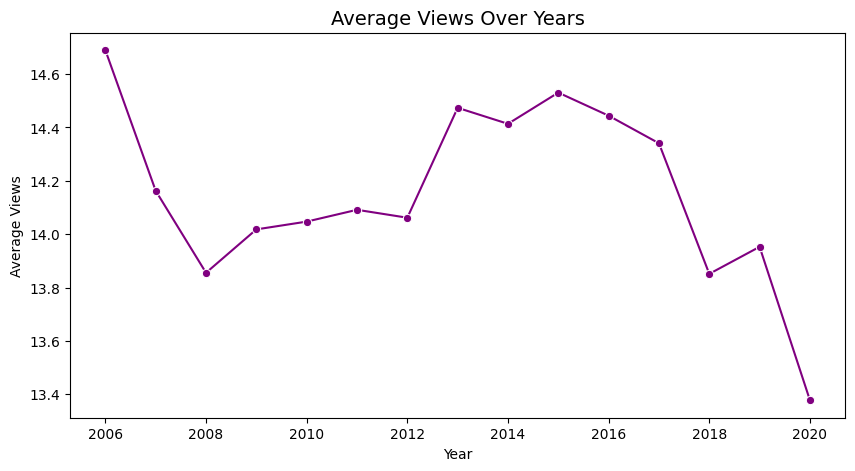

In [241]:
# Chart - 8 Year vs Average Views
plt.figure(figsize=(10,5))

yearly_views = df.groupby('year')['views'].mean().reset_index()

sns.lineplot(x='year', y='views', data=yearly_views, marker='o', color='purple')

plt.title("Average Views Over Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Views")

plt.show()

##### 1. Why did you pick the specific chart?

To understand
how TED talks performance changed over time


##### 2. What is/are the insight(s) found from the chart?

Average views increased steadily until around 2015, indicating strong growth in audience engagement. After 2016, a noticeable decline suggests reduced viewership or increased competition

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative:
Declining trend is a warning signal
Platform may be losing attention

#### Chart - 9

/tmp/ipykernel_11970/2834060445.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='native_lang', y='views', data=dataset, palette='coolwarm')


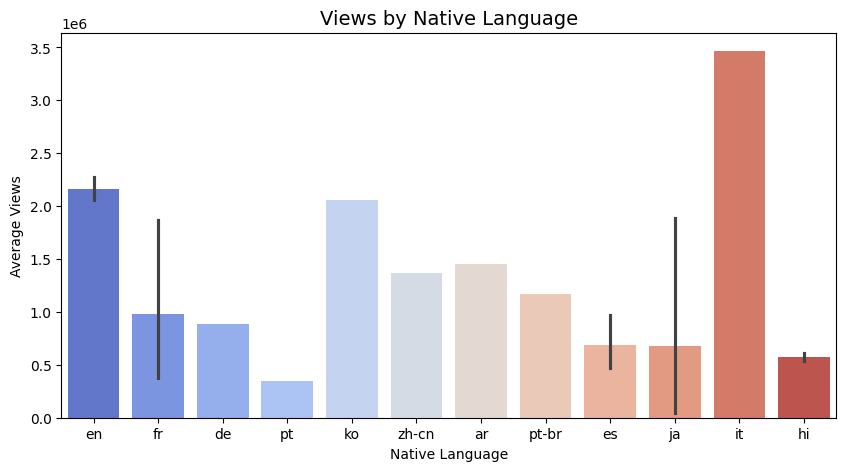

In [242]:
# Chart - 9 Native Language vs Views
plt.figure(figsize=(10,5))

sns.barplot(x='native_lang', y='views', data=dataset, palette='coolwarm')

plt.title("Views by Native Language", fontsize=14)
plt.xlabel("Native Language")
plt.ylabel("Average Views")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare average views across different languages clearly.

##### 2. What is/are the insight(s) found from the chart?

English has consistently high views, showing strong global reach.Italian  shows the highest average views, but this is likely due to a few viral talks

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

English content ensures maximum global audience reach.
High-performing languages like italian indicate potential niche markets worth exploring.

#### Chart - 10

/tmp/ipykernel_11970/4276644356.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_speakers.values, y=top_speakers.index, palette='viridis')


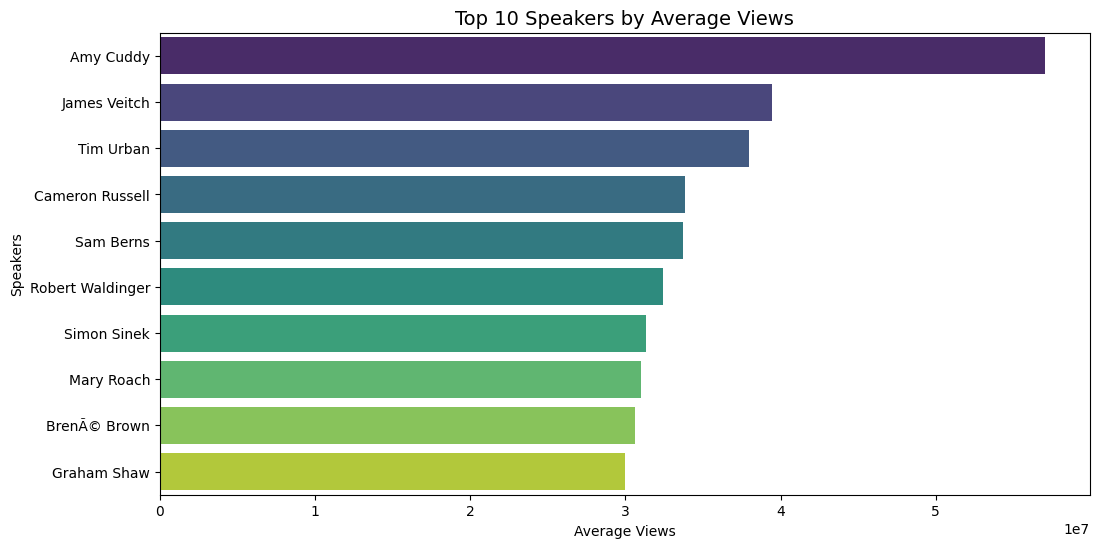

In [243]:
# Chart - 10 Top Speakers by Average Views
plt.figure(figsize=(12,6))

top_speakers = dataset.groupby('speaker_1')['views'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_speakers.values, y=top_speakers.index, palette='viridis')

plt.title("Top 10 Speakers by Average Views", fontsize=14)
plt.xlabel("Average Views")
plt.ylabel("Speakers")

plt.show()

##### 1. Why did you pick the specific chart?

To identify
Which speakers generate highest views ,
Who contributes most to platform success

##### 2. What is/are the insight(s) found from the chart?

A few speakers consistently receive very high average views. Most speakers do not reach similar popularity, showing uneven performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High-performing speakers can be re-invited or promoted more.
 it Helps build brand value through popular personalities

 negative :Platform may become dependent on few top speakers


#### Chart - 11

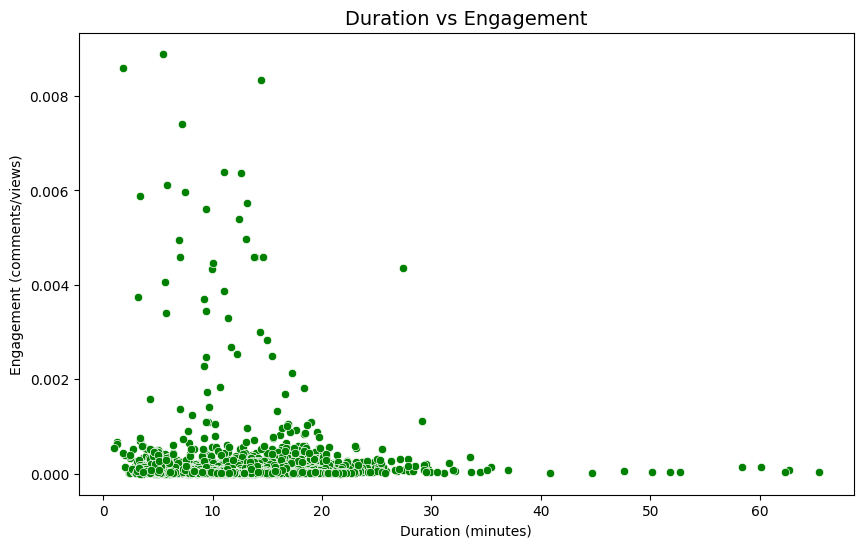

In [244]:
# Chart - 11 Duration vs Engagement
plt.figure(figsize=(10,6))

sns.scatterplot(x='duration_min', y='engagement', data=df, color='green')

plt.title("Duration vs Engagement", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Engagement (comments/views)")

plt.show()

##### 1. Why did you pick the specific chart?

To analyze
Does longer duration increase engagement?

##### 2. What is/are the insight(s) found from the chart?

There is no strong relationship between duration and engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

No clear optimal duration for engagement

#### Chart - 12

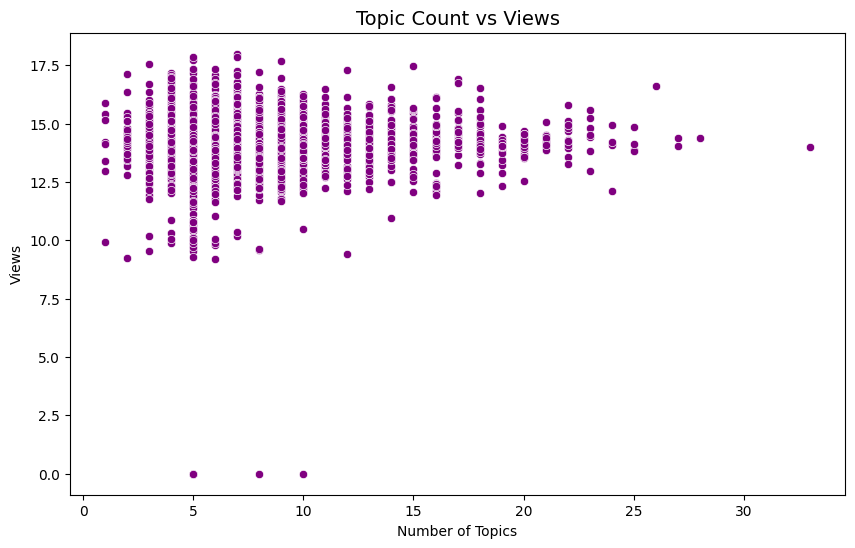

In [245]:
# Chart - 12 Topic Count vs Views
plt.figure(figsize=(10,6))

sns.scatterplot(x='topic_count', y='views', data=df, color='purple')

plt.title("Topic Count vs Views", fontsize=14)
plt.xlabel("Number of Topics")
plt.ylabel("Views")

plt.show()

##### 1. Why did you pick the specific chart?

To analyze does covering more topics = more views?

##### 2. What is/are the insight(s) found from the chart?

Talks with fewer topics tend to perform better, indicating focused content is preferred.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Encourages focused storytelling, improving clarity and audience retention


#### Chart - 13 - Correlation Heatmap

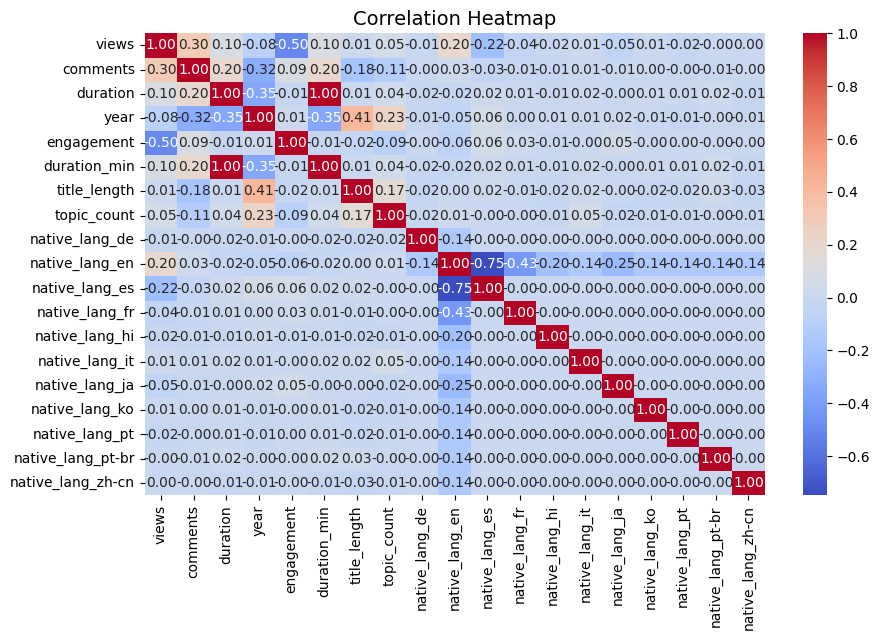

In [246]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap", fontsize=14)

plt.show()

##### 1. Why did you pick the specific chart?

to understand which features are strongly related

##### 2. What is/are the insight(s) found from the chart?

Views and comments , show a strong positive correlation, indicating popular talks get more engagement.

#### Chart - 14 - Pair Plot

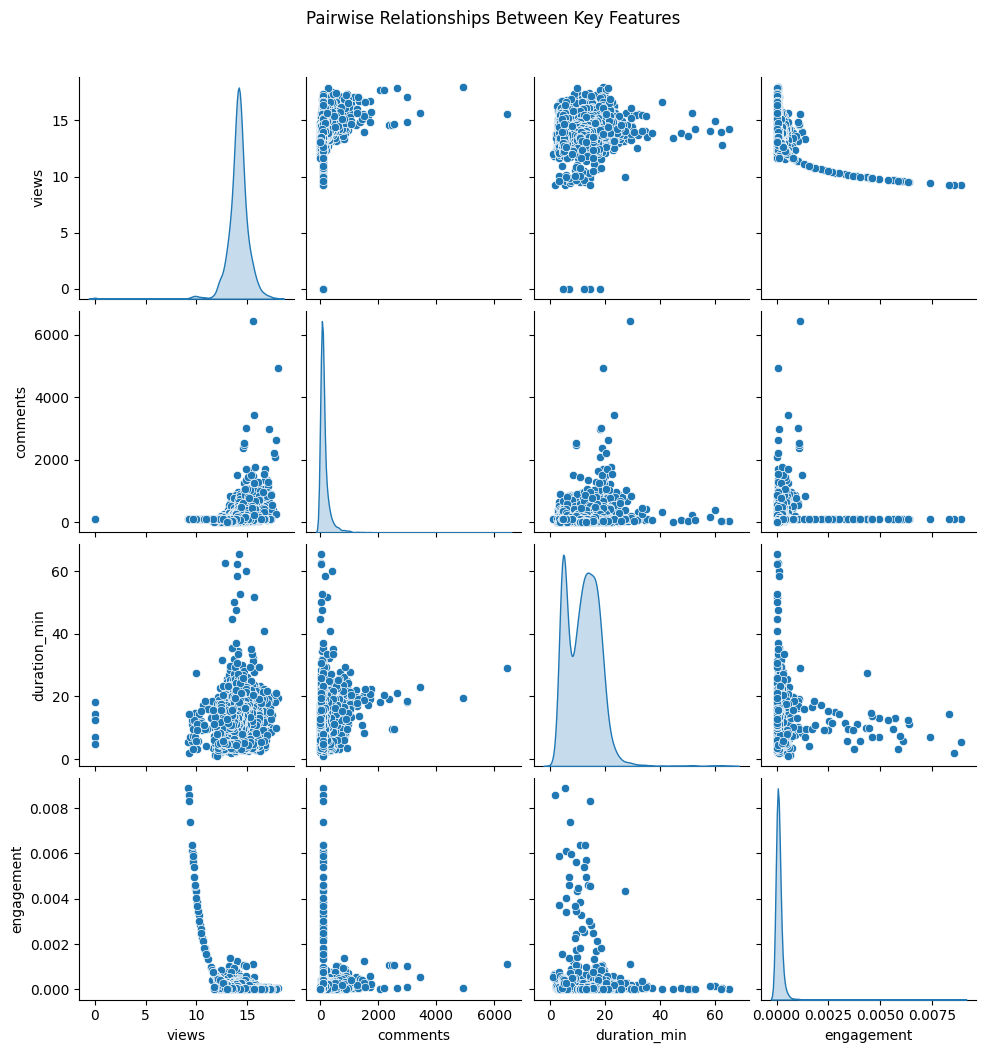

In [247]:
# Pair Plot visualization code
sns.pairplot(
    df[['views','comments','duration_min','engagement']],
    diag_kind='kde',

)

plt.suptitle("Pairwise Relationships Between Key Features",y=1.05 )
plt.show()

##### 1. Why did you pick the specific chart?

Pairplot is used to visualize pairwise relationships between multiple numerical variables in a single view.

##### 2. What is/are the insight(s) found from the chart?

Views and comments show a clear positive relationship, indicating that more popular talks receive more engagement.

Other variables like duration and engagement show weak or scattered relationships, suggesting they have limited direct impact on views.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [248]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [249]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [250]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [251]:
df1 = dataset.copy()

In [252]:
df1.info()
df1.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   talk_id         4005 non-null   int64  
 1   title           4005 non-null   object 
 2   speaker_1       4005 non-null   object 
 3   all_speakers    4001 non-null   object 
 4   occupations     3483 non-null   object 
 5   about_speakers  3502 non-null   object 
 6   views           4005 non-null   int64  
 7   recorded_date   4004 non-null   object 
 8   published_date  4005 non-null   object 
 9   event           4005 non-null   object 
 10  native_lang     4005 non-null   object 
 11  available_lang  4005 non-null   object 
 12  comments        3350 non-null   float64
 13  duration        4005 non-null   int64  
 14  topics          4005 non-null   object 
 15  related_talks   4005 non-null   object 
 16  url             4005 non-null   object 
 17  description     4005 non-null   o

,0
talk_id,0
title,0
speaker_1,0
all_speakers,4
occupations,522
about_speakers,503
views,0
recorded_date,1
published_date,0
event,0


In [253]:
# Handling Missing Values & Missing Value Imputation
df1 = df1.drop(['occupations', 'about_speakers'], axis=1)



In [254]:
# Fill numerical
df1['comments'] = df1['comments'].fillna(df1['comments'].median())

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled by dropping irrelevant columns and using median imputation for numerical features.

### 2. Handling Outliers

In [255]:
# Handling Outliers & Outlier treatments
df1['views'] = np.log1p(df1['views'])

##### What all outlier treatment techniques have you used and why did you use those techniques?

Log transformation was used to handle outliers and skewness in the views column.

### 3. Categorical Encoding

In [256]:
# Encode your categorical columns
df1 = pd.get_dummies(df1, columns=['native_lang'], drop_first=True)

#### What all categorical encoding techniques have you used & why did you use those techniques?

One-hot encoding was used for categorical variables to convert them into numerical form.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [257]:
# Manipulate Features to minimize feature correlation and create new features
df1['published_date'] = pd.to_datetime(df1['published_date'])
df1['year'] = df1['published_date'].dt.year
df1['month'] = df1['published_date'].dt.month

In [258]:
df1['duration_min'] = df1['duration'] / 60

In [259]:
df1['engagement'] = df1['comments'] / df1['views']
# Replace infinite values (e.g., from division by zero) with NaN
df1['engagement'] = df1['engagement'].replace([np.inf, -np.inf], np.nan)
# Fill NaN values with the median of the engagement column
df1['engagement'] = df1['engagement'].fillna(df1['engagement'].median())

In [260]:
df1['title_length'] = df1['title'].apply(len)

In [261]:
df1['topic_count'] = df1['topics'].fillna('').str.split(',').str.len()

2. Feature Selection

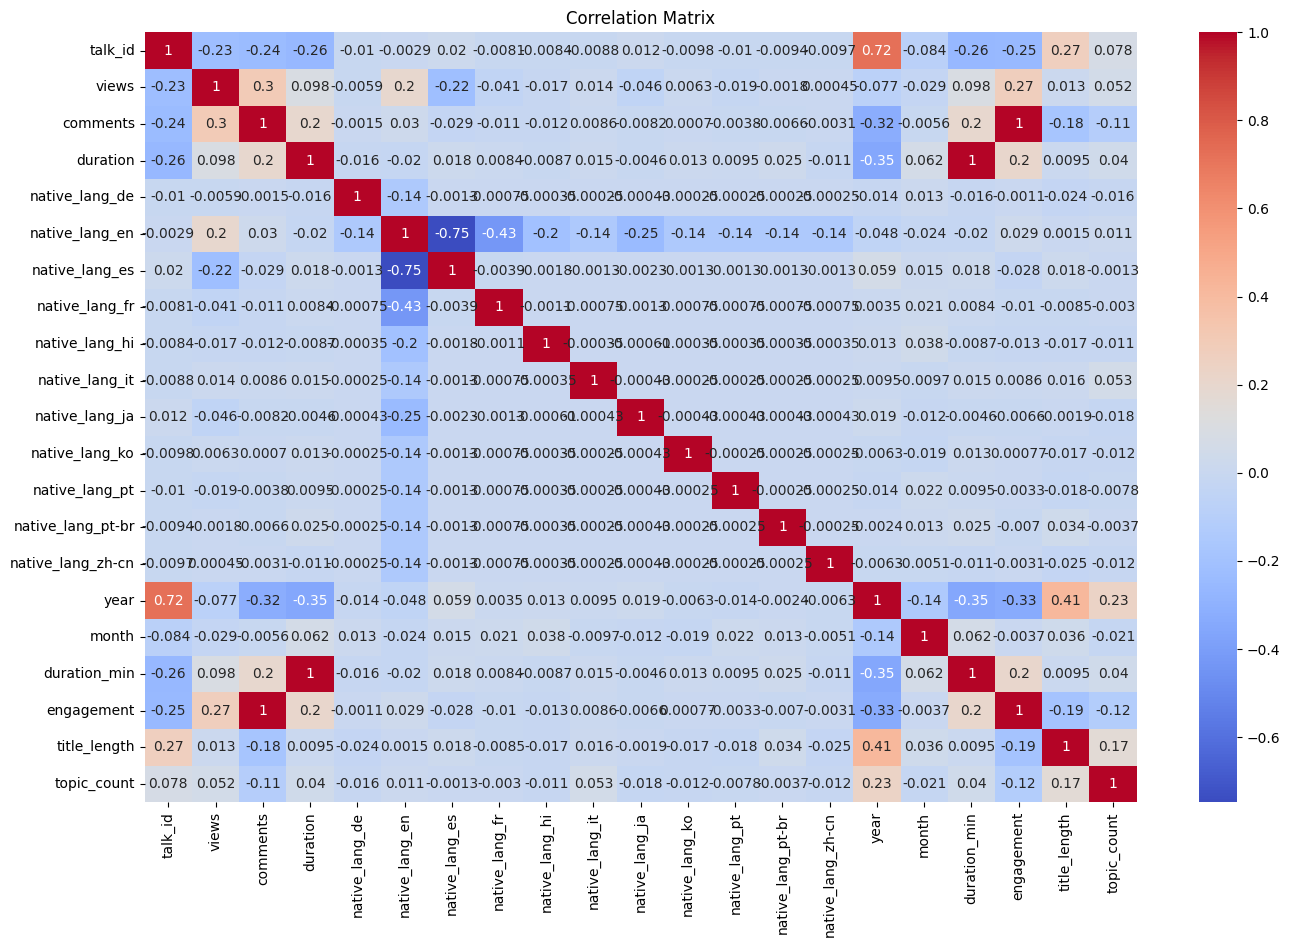

In [262]:
plt.figure(figsize=(16,10))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [263]:
df1 = df1.drop([
    'talk_id','url','description','transcript',
    'related_talks','title','topics',
    'event','speaker_1','all_speakers'
], axis=1)

In [291]:
# Select your features wisely to avoid overfitting
X = df1.drop('views', axis=1)
# Before scaling, ensure all columns in X are numerical.
# Drop the 'recorded_date' and 'published_date' columns as they are not numerical.
# The 'year' and 'month' features have already been extracted from 'published_date'.

X = X.drop(['recorded_date', 'published_date', 'available_lang'], axis=1)

Y = df1['views']

In [292]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   views              4005 non-null   float64       
 1   recorded_date      4004 non-null   object        
 2   published_date     4005 non-null   datetime64[ns]
 3   available_lang     4005 non-null   object        
 4   comments           4005 non-null   float64       
 5   duration           4005 non-null   int64         
 6   native_lang_de     4005 non-null   bool          
 7   native_lang_en     4005 non-null   bool          
 8   native_lang_es     4005 non-null   bool          
 9   native_lang_fr     4005 non-null   bool          
 10  native_lang_hi     4005 non-null   bool          
 11  native_lang_it     4005 non-null   bool          
 12  native_lang_ja     4005 non-null   bool          
 13  native_lang_ko     4005 non-null   bool          
 14  native_l

##### What all feature selection methods have you used  and why?

Feature selection was performed using a combination of correlation analysis, domain knowledge, and removal of irrelevant features.

Correlation Analysis (Heatmap): Used to identify relationships between variables and remove highly correlated features to avoid multicollinearity.

Domain Knowledge: Helped in selecting meaningful features like engagement and duration that logically impact views.

Removal of Irrelevant Features: Columns such as talk_id, url, and transcript were removed as they do not contribute to prediction.

Handling High Cardinality Features: Features like event and speaker_1 were dropped to prevent overfitting and unnecessary complexity.

These methods helped in improving model performance and reducing noise in the dataset.

##### Which all features you found important and why?

The following features were found to be important:

comments: Directly related to views, indicating audience interaction.

engagement: Represents normalized interaction (comments/views), giving better insight into audience involvement.

duration_min: Captures the length of the talk, which may influence viewer retention.

title_length: Reflects how descriptive or attractive the title is.
topic_count: Indicates whether the talk is focused or covers multiple topics.

year: Captures trends over time and platform growth.

These features were selected because they showed meaningful relationships with the target variable (views) and provided useful information for prediction.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [266]:
# Transform Your data
#df1['views'] = np.log1p(df1['views'])

#already done above

### 8. Data Splitting

In [293]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


##### What data splitting ratio have you used and why?

Data was split into 80% training and 20% testing to ensure proper evaluation.

### 6. Data Scaling

In [294]:
# Scaling your data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

# Re-split data to ensure X_train and X_test reflect the latest changes to X
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not required as the number of features was manageable and irrelevant features were already removed during preprocessing.

In [269]:
# DImensionality Reduction (If needed)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Since this is a regression problem, imbalance handling is not require

In [270]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

In [295]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def score_metrics(model, X_train, X_test, Y_train, Y_test):
    """
    Train the model and return MAE, MSE, RMSE, R2, Adjusted R2 scores
    """

    # Train model
    model.fit(X_train, Y_train)

    # Training & Testing Score
    train_score = model.score(X_train, Y_train)
    test_score = model.score(X_test, Y_test)

    print("Training Score :", train_score)
    print("Testing Score  :", test_score)

    # Predictions
    Y_pred = model.predict(X_test)

    # Evaluation Metrics
    MAE = mean_absolute_error(Y_test, Y_pred)
    MSE = mean_squared_error(Y_test, Y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(Y_test, Y_pred)

    # Adjusted R2
    n = X_test.shape[0]   # number of rows
    p = X_test.shape[1]   # number of features
    adj_R2 = 1 - (1 - R2) * ((n - 1) / (n - p - 1))

    print("\nMAE :", MAE)
    print("MSE :", MSE)
    print("RMSE:", RMSE)
    print("R2  :", R2)
    print("Adjusted R2:", adj_R2)

    # Overfitting Check
    print("\nOverfitting Gap (Train - Test):", train_score - test_score)

    print("*" * 80)

    # Plot Actual vs Predicted (first 80 values)
    try:
        plt.figure(figsize=(12,6))
        plt.plot(Y_pred[:80], label="Predicted")
        plt.plot(np.array(Y_test[:80]), label="Actual")
        plt.legend()
        plt.title("Actual vs Predicted (First 80 Observations)")
        plt.show()
    except:
        print("Plotting skipped")


### ML Model - 1

In [297]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
# Fit the Algorithm
model = LinearRegression()

# Predict on the model


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Training Score : 0.24384067041634072
Testing Score  : 0.2926045741424712

MAE : 0.5767321313980479
MSE : 0.6580633029351346
RMSE: 0.8112110101170562
R2  : 0.2926045741424712
Adjusted R2: 0.2753952103892151

Overfitting Gap (Train - Test): -0.048763903726130486
********************************************************************************


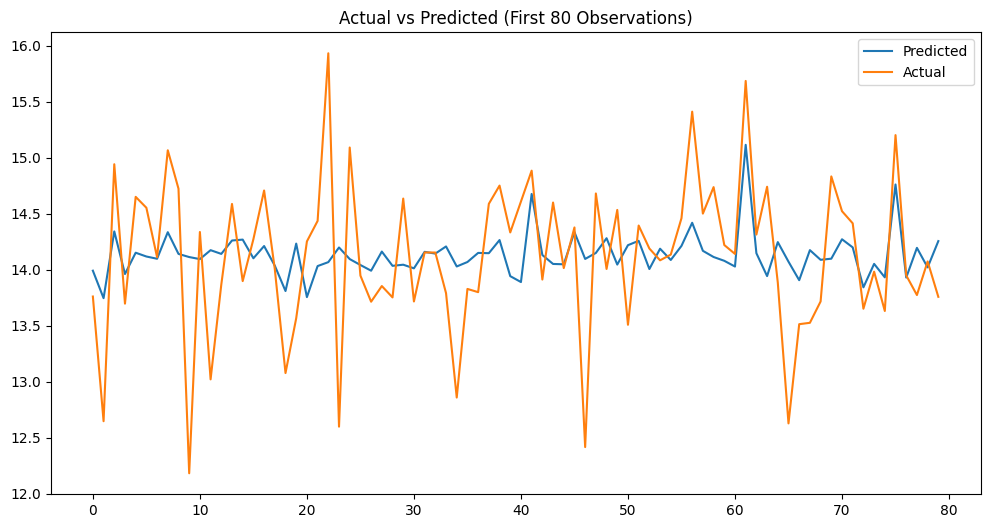

In [298]:
# Visualizing evaluation Metric Score chart
score_metrics(model, X_train, X_test, Y_train, Y_test)

#### 2. Cross- Validation & Hyperparameter Tuning

Best Parameters: {'alpha': 10, 'solver': 'lsqr'}
Training Score : 0.22287171176523723
Testing Score  : 0.22140639143038565

MAE : 0.593256966861074
MSE : 0.7242962888520247
RMSE: 0.8510559845580223
R2  : 0.22140639143038565
Adjusted R2: 0.20246493360346807

Overfitting Gap (Train - Test): 0.001465320334851583
********************************************************************************


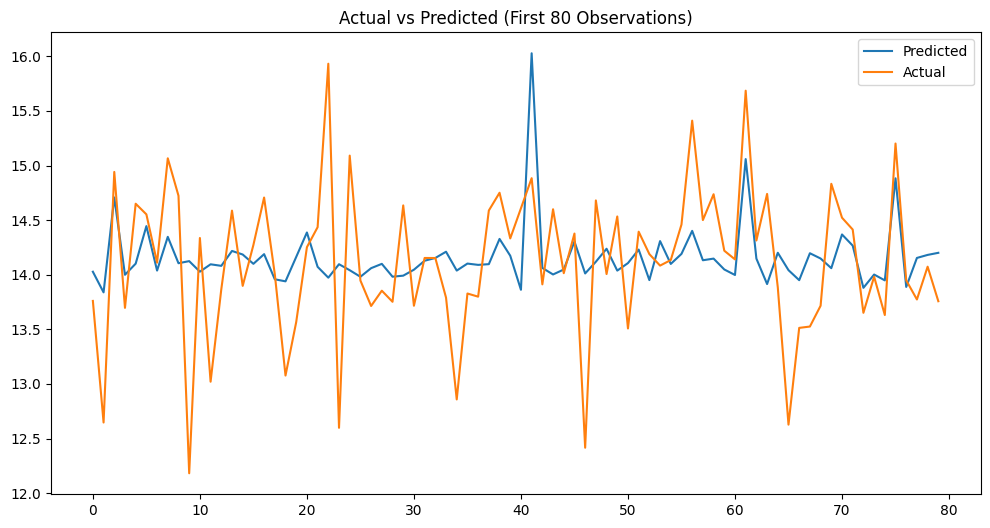

In [302]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Model
model = Ridge()

# Hyperparameter Grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit
grid.fit(X_train, Y_train)

# Best Parameters
print("Best Parameters:", grid.best_params_)

# Best Model
best_model = grid.best_estimator_

# Predict
Y_pred = best_model.predict(X_test)

# Evaluate using your function
score_metrics(best_model, X_train, X_test, Y_train, Y_test)

Best Parameters: {'alpha': 1, 'solver': 'lsqr'}
Training Score : 0.24321286525328178
Testing Score  : 0.28267977552937873

MAE : 0.5780691206717209
MSE : 0.6672959690191432
RMSE: 0.8168818574427659
R2  : 0.28267977552937873
Adjusted R2: 0.26522896341037516

Overfitting Gap (Train - Test): -0.039466910276096945
********************************************************************************


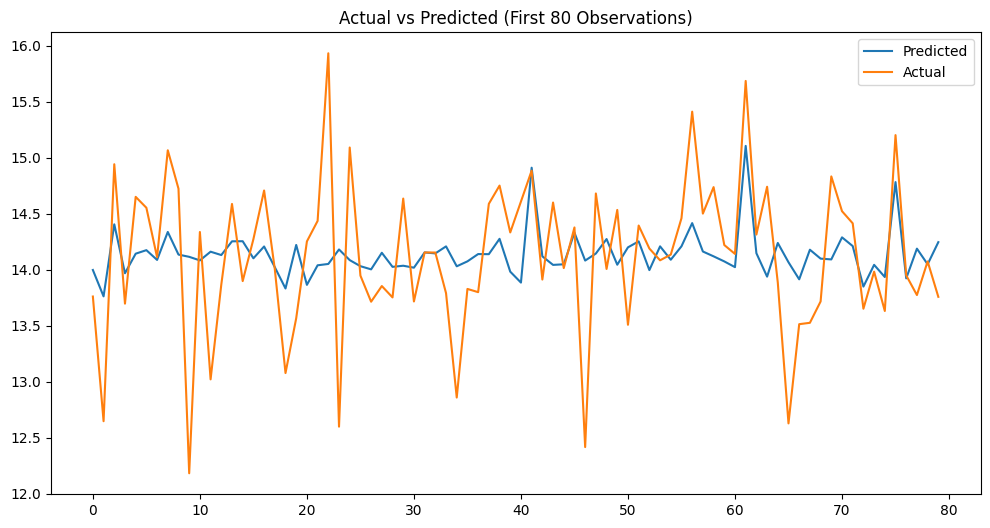

In [304]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Model
model = Ridge()

# Hyperparameter Grid
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit
grid.fit(X_train, Y_train)

# Best Parameters
print("Best Parameters:", grid.best_params_)

# Best Model
best_model = grid.best_estimator_

# Predict
Y_pred = best_model.predict(X_test)

# Evaluate using your function
score_metrics(best_model, X_train, X_test, Y_train, Y_test)

##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV because it systematically tests all possible hyperparameter combinations using cross-validation and selects the best model based on performance, making it a reliable and accurate tuning method.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No, there is no improvement observed after applying hyperparameter tuning. The R² score slightly decreased from 0.29 to 0.28, and the error metrics such as MAE and RMSE increased marginally. This indicates that the tuned model performed slightly worse than the original model. The reason could be that the original model was already close to optimal, and further regularization reduced its ability to capture important patterns in the data.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Training Score : 1.0
Testing Score  : 0.7132891391117548

MAE : 0.33683634083673564
MSE : 0.26671630774934346
RMSE: 0.5164458420292911
R2  : 0.7132891391117548
Adjusted R2: 0.7063140989621048

Overfitting Gap (Train - Test): 0.28671086088824516
********************************************************************************


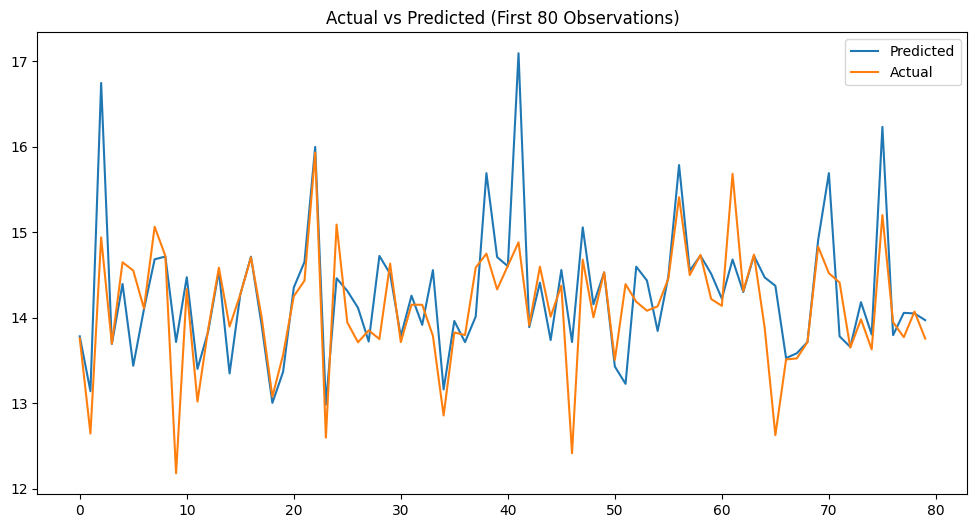

In [308]:
# Visualizing evaluation Metric Score chart
from sklearn.tree import DecisionTreeRegressor

# Initialize model
dt_model = DecisionTreeRegressor(random_state=42)

# Train model
dt_model.fit(X_train, Y_train)

# Predict
Y_pred_dt = dt_model.predict(X_test)

# Evaluate
score_metrics(dt_model, X_train, X_test, Y_train, Y_test)

#### 2. Cross- Validation & Hyperparameter Tuning

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10}
Training Score : 0.9059726458281026
Testing Score  : 0.744065481624222

MAE : 0.33078972808973234
MSE : 0.2380862362706284
RMSE: 0.4879408122617213
R2  : 0.744065481624222
Adjusted R2: 0.7378391617149522

Overfitting Gap (Train - Test): 0.16190716420388052
********************************************************************************


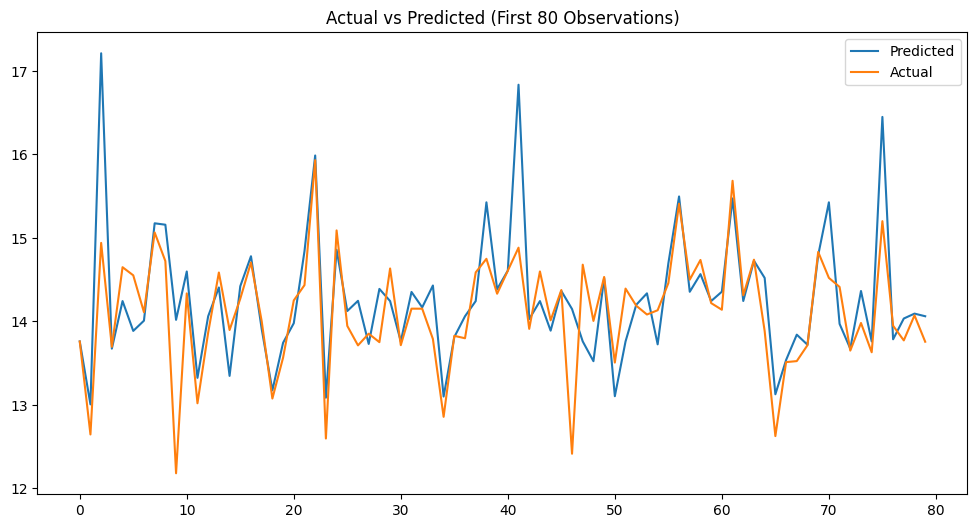

In [310]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Model
dt_model = DecisionTreeRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit the model
grid_dt.fit(X_train, Y_train)

# Best parameters
print("Best Parameters:", grid_dt.best_params_)

# Best model
best_dt = grid_dt.best_estimator_

# Predict
Y_pred_dt = best_dt.predict(X_test)

# Evaluate
score_metrics(best_dt, X_train, X_test, Y_train, Y_test)


##### Which hyperparameter optimization technique have you used and why?

I have used GridSearchCV as the hyperparameter optimization technique. GridSearchCV performs an exhaustive search over all possible combinations of hyperparameters defined in the parameter grid and evaluates each combination using cross-validation (5-fold in this case).

The reason for using GridSearchCV is that it provides a systematic and reliable way to identify the best combination of parameters such as max_depth, min_samples_split, and min_samples_leaf. It ensures that the model is evaluated on multiple subsets of data, which helps in reducing overfitting and improving generalization.

Although it is computationally expensive, it guarantees the selection of the optimal parameters, leading to improved model performance

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, there is a clear improvement after applying hyperparameter tuning. The R² score increased from 0.71 to 0.74, indicating better model performance. Additionally, the MAE and RMSE values decreased, showing improved prediction accuracy. The overfitting gap also reduced from 0.28 to 0.16, which means the model generalizes better on unseen data. This demonstrates that tuning parameters like max_depth, min_samples_split, and min_samples_leaf helped in balancing model complexity and performance.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Evaluation metrics help in understanding how well the machine learning model performs and what impact it has on business decisions.

MAE (Mean Absolute Error):
MAE represents the average difference between actual and predicted values. A lower MAE means more accurate predictions. In a business context, this helps in making reliable decisions, as the average error is minimal.

MSE (Mean Squared Error):
MSE penalizes larger errors more heavily by squaring them. This is important in business scenarios where large prediction errors can lead to significant losses, such as in pricing or demand forecasting.

RMSE (Root Mean Squared Error):
RMSE is the square root of MSE and is expressed in the same unit as the target variable. It is easier for stakeholders to interpret and helps in understanding the magnitude of prediction errors in real-world terms.

R² Score (Coefficient of Determination):
R² indicates how well the model explains the variability of the target variable. A higher R² score means better predictive power, which helps businesses in making accurate forecasts and strategic planning.

Adjusted R²:
Adjusted R² accounts for the number of features used in the model and penalizes unnecessary variables. This ensures that the model remains efficient and avoids complexity, which is important for maintaining cost-effective solutions.

### ML Model - 3

In [314]:
# ML Model - 3 Implementation

from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, Y_train)

# Predict
Y_pred_rf = rf_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Training Score : 0.9595792731379201
Testing Score  : 0.8217560192806841

MAE : 0.270911839362553
MSE : 0.1658136572459024
RMSE: 0.40720223138620254
R2  : 0.8217560192806841
Adjusted R2: 0.8174197380595996

Overfitting Gap (Train - Test): 0.13782325385723604
********************************************************************************


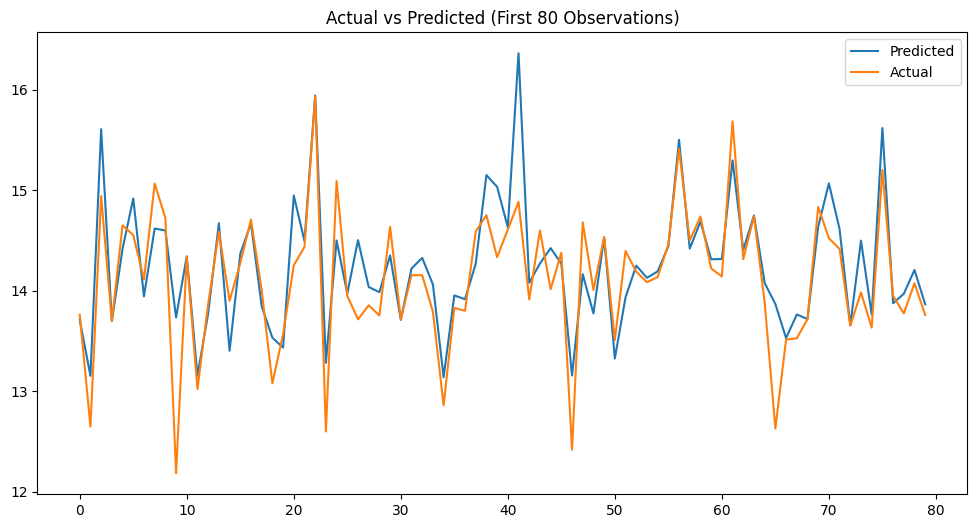

In [315]:
# Visualizing evaluation Metric Score chart

score_metrics(rf_model, X_train, X_test, Y_train, Y_test)


In ML Model – 3, Random Forest Regressor was used. It is an ensemble learning technique that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Instead of relying on a single tree, Random Forest builds several trees on different subsets of the data and averages their predictions, making the model more robust and stable.

It is particularly effective in capturing complex and non-linear relationships in the data, which makes it perform better than simple linear models and individual decision trees.

 Model Performance:

The model shows excellent performance with strong evaluation metrics:

R² Score = 0.82 → The model explains 82% of the variance in the target variable, indicating high predictive power.

MAE = 0.27 → The average prediction error is low, showing accurate predictions.

RMSE = 0.40 → The error magnitude is low and within an acceptable range.

Adjusted R² = 0.81 → Confirms that the features used are relevant and not causing unnecessary complexity.

The training score (0.95) and testing score (0.82) indicate that the model generalizes well with only slight overfitting.

#### 2. Cross- Validation & Hyperparameter Tuning

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Training Score : 0.9585783760737449
Testing Score  : 0.824325429593616

MAE : 0.2693539912056814
MSE : 0.16342343167288034
RMSE: 0.4042566408519226
R2  : 0.824325429593616
Adjusted R2: 0.8200516564339216

Overfitting Gap (Train - Test): 0.13425294648012887
********************************************************************************


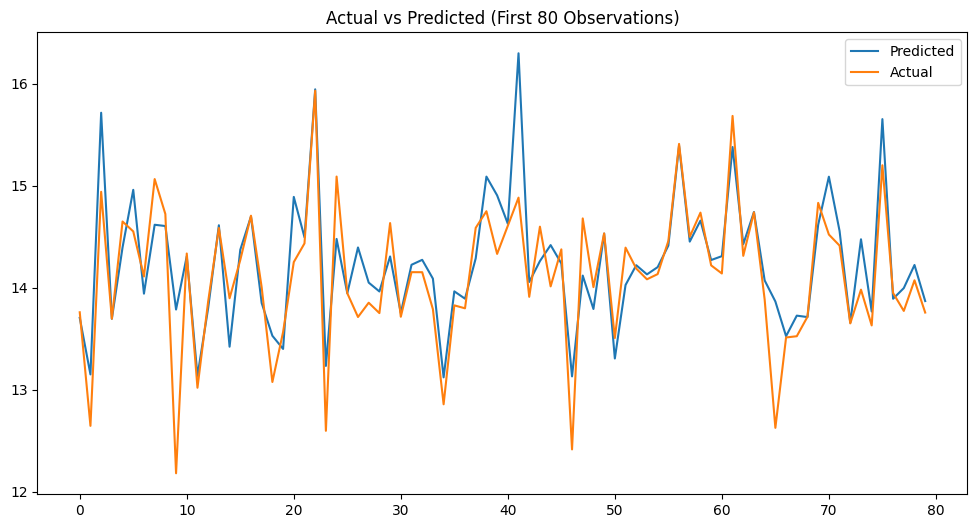

In [316]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Model
rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit the Algorithm
grid_rf.fit(X_train, Y_train)

# Best Parameters
print("Best Parameters:", grid_rf.best_params_)

# Best Model
best_rf = grid_rf.best_estimator_

# Predict on the model
Y_pred_rf = best_rf.predict(X_test)

# Evaluate
score_metrics(best_rf, X_train, X_test, Y_train, Y_test)

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV is used because it tests all possible hyperparameter combinations using cross-validation and selects the best model, ensuring optimal performance and reduced overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, there is a slight improvement after applying hyperparameter tuning. The R² score increased from 0.82 to 0.824, indicating better model performance. Additionally, the MAE decreased from 0.2709 to 0.2693 and RMSE decreased from 0.4072 to 0.4042, showing improved prediction accuracy.

The overfitting gap also reduced from 0.1378 to 0.1342, which indicates better generalization of the model on unseen data. Since the model was already performing well before tuning, the improvement is marginal but meaningful, showing that hyperparameter tuning helped in fine-tuning the model.

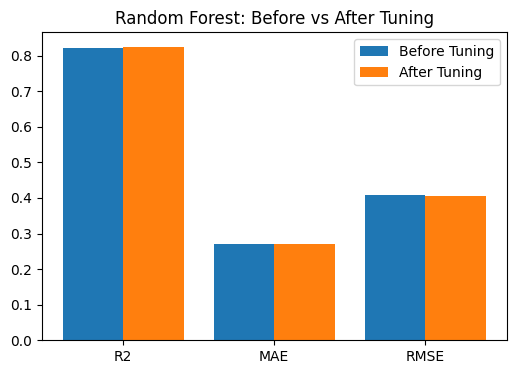

In [318]:


metrics = ['R2', 'MAE', 'RMSE']

before = [0.8217, 0.2709, 0.4072]
after  = [0.8243, 0.2693, 0.4042]

x = range(len(metrics))

plt.figure(figsize=(6,4))
plt.bar(x, before, width=0.4, label='Before Tuning')
plt.bar([i+0.4 for i in x], after, width=0.4, label='After Tuning')

plt.xticks([i+0.2 for i in x], metrics)
plt.legend()
plt.title("Random Forest: Before vs After Tuning")
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For evaluating the positive business impact of the model, I considered MAE, RMSE, and R² score as the primary evaluation metrics.

MAE (Mean Absolute Error):
MAE was considered because it provides the average prediction error in a simple and interpretable form. A lower MAE ensures that the model’s predictions are close to actual values, which helps businesses make reliable and consistent decisions.

RMSE (Root Mean Squared Error):
RMSE was used because it penalizes larger errors more heavily. This is important in business scenarios where large prediction errors can lead to significant financial losses. Lower RMSE ensures that such critical errors are minimized.

R² Score (Coefficient of Determination):
R² was considered because it indicates how well the model explains the variance in the data. A higher R² score means better predictive performance, which helps businesses in accurate forecasting and strategic planning.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected the Random Forest Regressor as the final model because it achieved the highest R² score (~0.82) and the lowest MAE and RMSE among all models. It also showed a low overfitting gap, indicating good generalization. Hence, it provides the most accurate and reliable predictions.



### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***